In [19]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd

from matplotlib.colors import ListedColormap

In [24]:
raster_path = r"C:\Users\eugea\Downloads\11_NDVI_inta_verano.tif"
cluster_path = r"C:\Users\eugea\Downloads\11_NDVI_inta_verano_gmm_k3(n_ver).tif"

with rasterio.open(raster_path) as src:
    data = src.read().astype(np.float32)
    bands, h, w = data.shape

with rasterio.open(cluster_path) as src:
    cluster_map = src.read(1)

# -----------------------------
# 2. ELIMINAR BANDA 1 (categórica)
# -----------------------------
data_no_clases = data[1:, :, :]   # solo bandas 2–12
bands, h, w = data_no_clases.shape

# -----------------------------
# 3. Flatten para análisis
# -----------------------------
X = data_no_clases.reshape(bands, -1).T
clusters = cluster_map.flatten()

valid = clusters >= 0
X = X[valid]
clusters = clusters[valid]

(np.float64(-0.5), np.float64(2797.5), np.float64(2896.5), np.float64(-0.5))

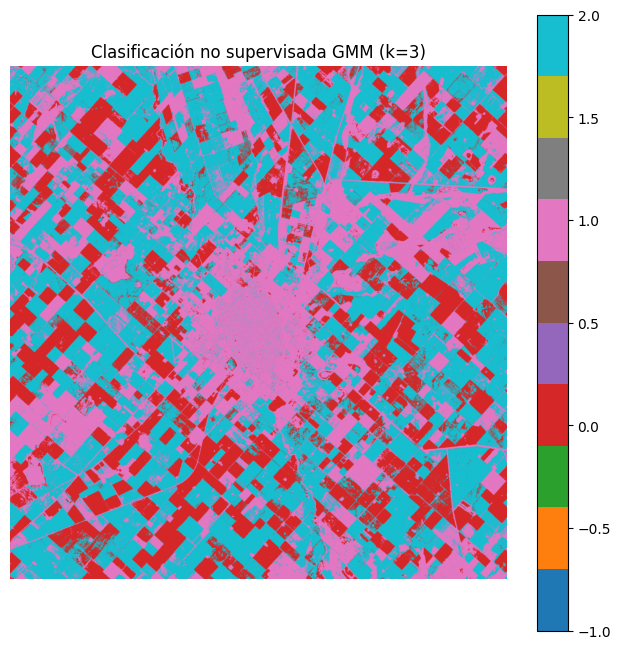

In [25]:
plt.figure(figsize=(8, 8))
plt.imshow(cluster_map, cmap="tab10")
plt.title("Clasificación no supervisada GMM (k=3)")
plt.colorbar()
plt.axis("off")


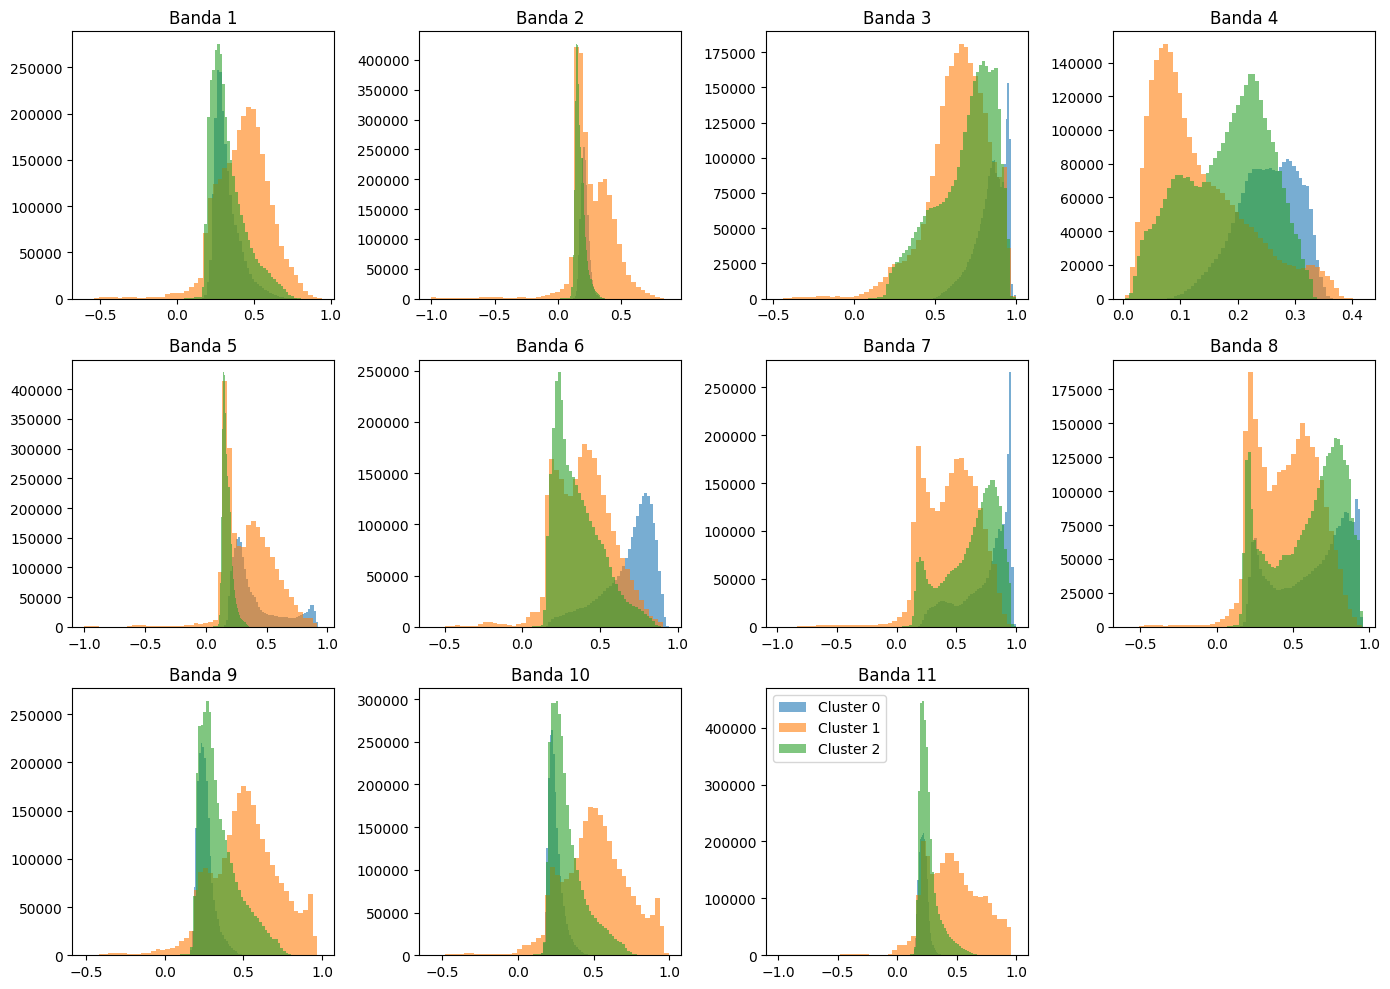

In [26]:
# --------------------------------------
# 2. Histogramas por cluster (bandas 1–11)
# --------------------------------------
plt.figure(figsize=(14, 10))
for i in range(min(11, X.shape[1])):
    plt.subplot(3, 4, i+1)
    for k in np.unique(clusters):
        plt.hist(X[clusters==k, i], bins=50, alpha=0.6, label=f"Cluster {k}")
    plt.title(f"Banda {i+1}")
    plt.tight_layout()

plt.legend()
plt.show()

c:\Users\eugea\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


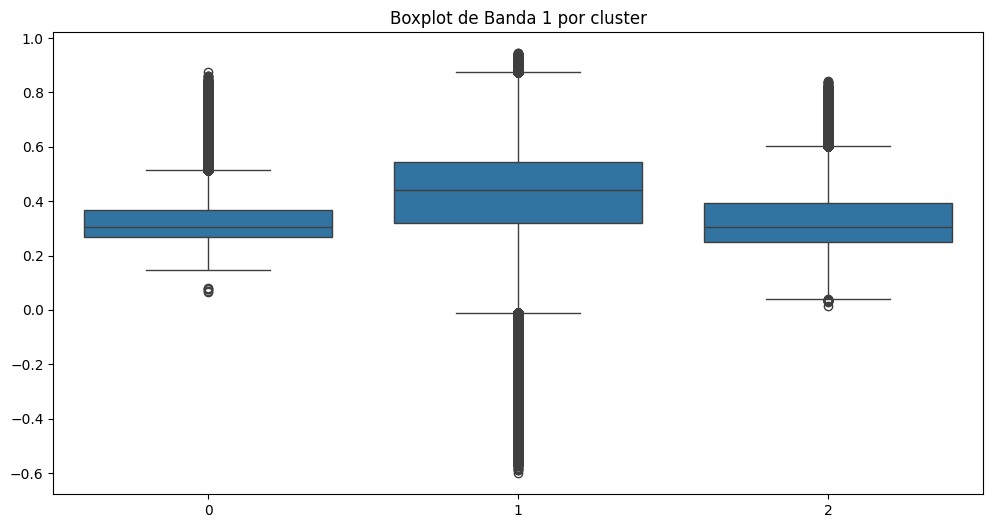

In [27]:
# --------------------------------------
# 3. Boxplots
# --------------------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(x=clusters, y=X[:, 0])  # banda 1 como ejemplo
plt.title("Boxplot de Banda 1 por cluster")
plt.show()

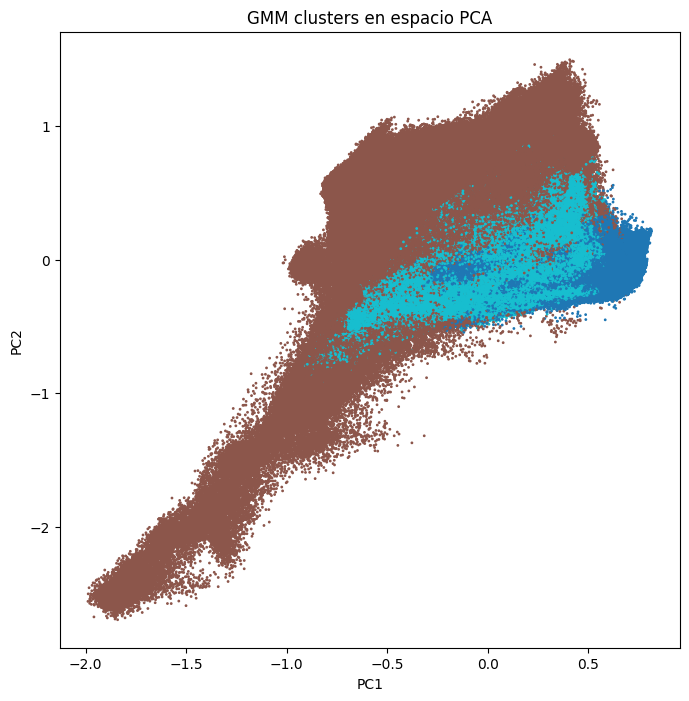

In [28]:
# --------------------------------------
# 4. PCA 2D coloreado por cluster
# --------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 8))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, s=1, cmap="tab10")
plt.title("GMM clusters en espacio PCA")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

In [29]:
print("Varianza explicada por PCA:", pca.explained_variance_ratio_)


Varianza explicada por PCA: [0.36715287 0.30146945]


Conclusión del análisis del modelo de mezcla GMM (k=3)

El modelo de mezcla Gaussiana (GMM) con k=3 identificó tres grupos principales dentro de los datos espectrales (NDVI mensual y estadísticas NDVI). La proyección PCA muestra que los clusters se separan en el espacio reducido, ungrupo es dominante y los otros dos capturan variaciones específicas. El boxplot de la banda INTA_verano confirma que los clusters presentan diferencias reales, lo que indica que el modelo está reconociendo patrones consistentes en los datos.

Los tres clusters obtenidos pueden interpretarse como candidatos a las categorías “barbecho”, “agrícola” y “no agrícola” que usamos en el modelo supervisado Random Forest. Pero para validar si tiene sentido agronómico, vamos a comparar los clusters con las clases de INTA a través de una tabla de contingencia. Para evaluar si cada categoría del INTA cae mayoritariamente dentro de un cluster específico. Si la correspondencia es clara, entonces el modelo de mezcla capta la estructura real del paisaje; si no, abría que ajustar el número de clusters.

In [30]:


# ============================================
# 1. Leer INTA y GMM
# ============================================

with rasterio.open(raster_path) as src:
    inta = src.read(1).astype(np.int32)

with rasterio.open(cluster_path) as src:
    gmm = src.read(1).astype(np.int32)

# ============================================
# 2. Aplanar
# ============================================

inta_flat = inta.flatten()
gmm_flat = gmm.flatten()

# Filtrar nodata (suponiendo que es 0 en INTA)
valid = inta_flat > 0

inta_flat = inta_flat[valid]
gmm_flat = gmm_flat[valid]

# ============================================
# 3. DataFrame y tablas
# ============================================

df = pd.DataFrame({
    "INTA": inta_flat,
    "GMM": gmm_flat
})

tabla = pd.crosstab(df["INTA"], df["GMM"])
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

# ============================================
# 4. Mostrar resultados
# ============================================

print("\n================ TABLA DE CONTINGENCIA ================\n")
display(tabla)

print("\n================ TABLA DE PORCENTAJES (%) ================\n")
display(tabla_pct.round(2))



================ TABLA DE CONTINGENCIA ================



GMM,-1,0,1,2
INTA,,,,
10,1,592462,76231,479212
11,5,840091,280459,1693974
12,0,446751,42596,20817
18,0,3821,4922,3733
21,13,5363,427196,701859
22,33,162570,1522880,506049
26,0,1011,0,0
255,1042,7078,264459,21178



================ TABLA DE PORCENTAJES (%) ================



GMM,-1,0,1,2
INTA,,,,
10,0.00,51.61,6.64,41.75
11,0.00,29.85,9.96,60.19
12,0.00,87.57,8.35,4.08
18,0.00,30.63,39.45,29.92
21,0.00,0.47,37.66,61.87
22,0.00,7.42,69.49,23.09
26,0.00,100.00,0.00,0.00
255,0.35,2.41,90.03,7.21


El modelo de mezcla gaussiana con k=3 separó de forma coherente las regiones en tres tipos. El análisis de la tabla de contingencia entre las clases del INTA y los clusters del GMM muestra que los clusters 0 y 2 representan dos estados distintos de actividad agrícola: uno asociado a suelos descubiertos o cultivos de menor vigor (cluster 0, barbechos) y otro asociado a cultivos activos con mayor NDVI (cluster 2 agrícola). Por otro lado, el cluster 1 agrupa mayoritariamente superficies no agrícolas, zonas urbanas, pastizales y también la mayoría de los píxeles catalogados como nodata por INTA (categoría 255).

La diferencia de zonas indica que k=3 es adecuado para separar agricultura(barbecho) – agricultura de alto vigor – no agrícola, incluso obteniendo una segmentación más fina que la clasificación INTA original. Por lo tanto, el GMM no solo reproduce la estructura general del paisaje sino que agrega información al subdividir clases agrícolas amplias en categorías fenológicas diferenciadas.

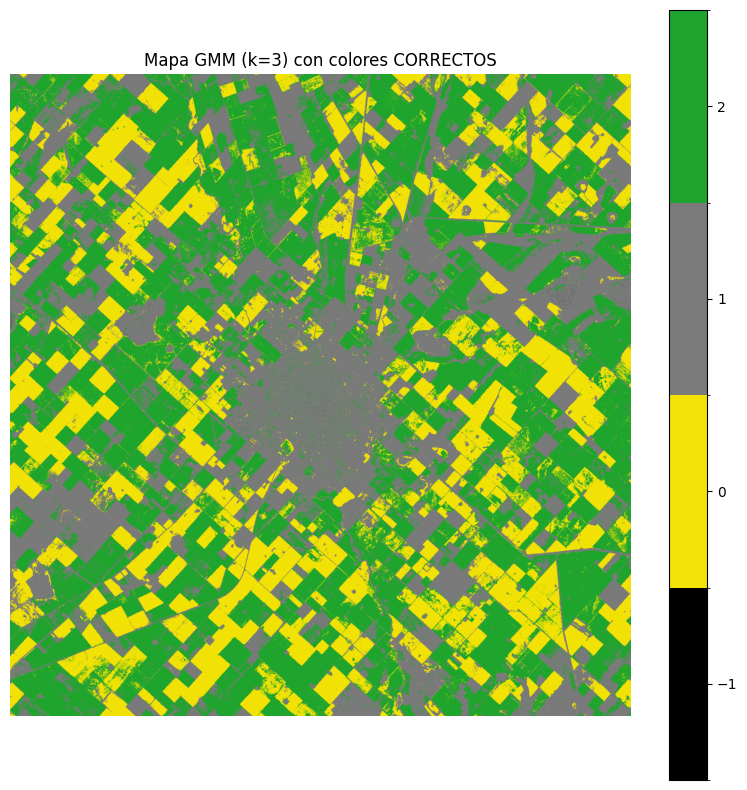

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm

cluster_map = cluster_map.astype(int)

# Definir colores por valor real del raster
colors = [
    "#000000",  # -1 nodata → negro
    "#F2E205",  # 0 → amarillo
    "#7A7A7A",  # 1 → gris
    "#1FA52D",  # 2 → verde
]

# Rangos exactos
bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, len(colors))

cmap = ListedColormap(colors)

plt.figure(figsize=(10,10))
plt.imshow(cluster_map, cmap=cmap, norm=norm)
plt.title("Mapa GMM (k=3) ")
plt.axis("off")
plt.colorbar(ticks=[-1,0,1,2])
plt.show()


Dimensiones: (2897, 2798)


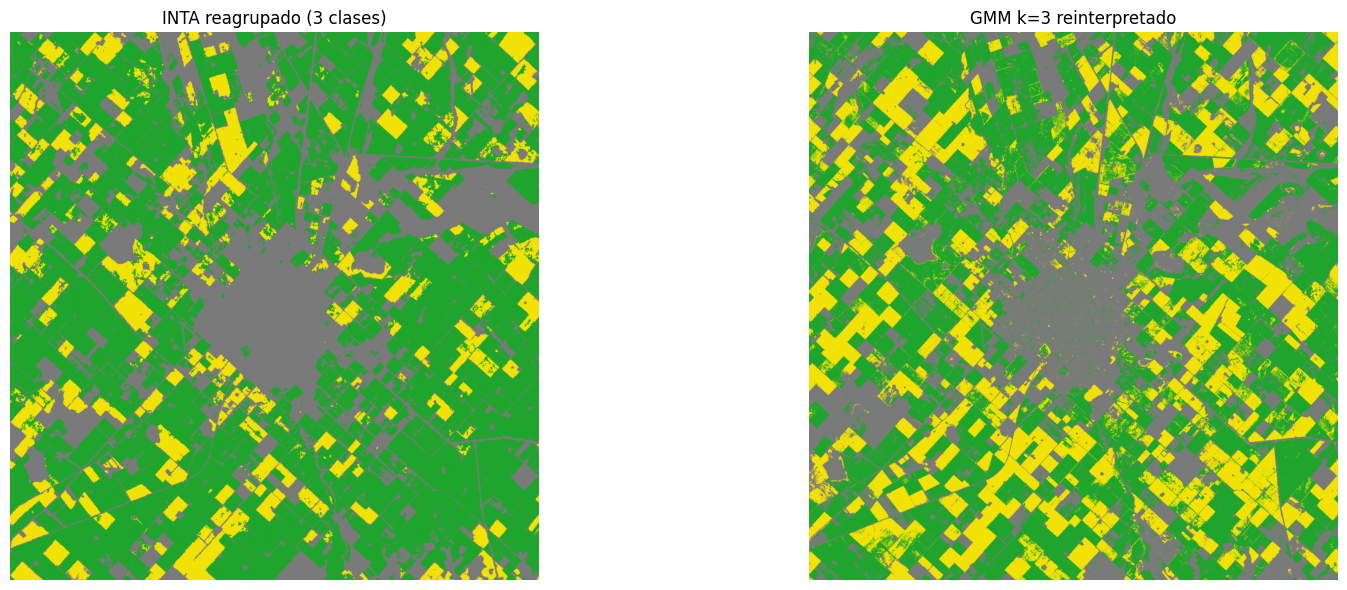

In [36]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ============================
# RUTAS
# ============================

raster_path = r"C:\Users\eugea\Downloads\11_NDVI_inta_verano.tif"
gmm_path = r"C:\Users\eugea\Downloads\11_NDVI_inta_verano_gmm_k3(n_ver).tif"


# ============================
# 1. LEER RASTERS
# ============================

with rasterio.open(raster_path) as src:
    inta = src.read(1)  # Banda 1 = categorías INTA
    h, w = inta.shape

with rasterio.open(gmm_path) as src:
    gmm = src.read(1)

print("Dimensiones:", inta.shape)


# ============================
# 2. RECLASIFICAR INTA (3 clases)
# ============================

# 0 → AGRICOLA
# 1 → BARBECHO
# 2 → NO AGRICOLA

agricola = [10, 11, 12, 18, 26]
barbecho = [21]
no_agricola = [22, 255]

inta_3 = np.full_like(inta, -1)

for v in agricola:
    inta_3[inta == v] = 0

for v in barbecho:
    inta_3[inta == v] = 1

for v in no_agricola:
    inta_3[inta == v] = 2


# ============================
# 3. DEFINIR COLORES
# ============================

# INTA original (8 categorías)
colors_inta = [
    "#66c2a5",  # 10
    "#fc8d62",  # 11
    "#8da0cb",  # 12
    "#e78ac3",  # 18
    "#a6d854",  # 21
    "#ffd92f",  # 22
    "#e5c494",  # 26
    "#b3b3b3",  # 255
]
cmap_inta = ListedColormap(colors_inta)

# INTA 3 clases
colors_inta3 = [
    "#1FA52D",  # verde agricola
    "#F2E205",  # amarillo barbecho
    "#7A7A7A"   # gris no agricola
]
cmap_inta3 = ListedColormap(colors_inta3)

# GMM reinterpretado
colors_gmm = [
    "#F2E205",  # cluster 0 → amarillo
    "#7A7A7A",  # cluster 1 → gris
    "#1FA52D"   # cluster 2 → verde
]
cmap_gmm = ListedColormap(colors_gmm)


# ============================
# 4. FIGURA FINAL DE COMPARACIÓN
# ============================

plt.figure(figsize=(18, 6))

# # ---- Mapa 1: INTA original ----
# plt.subplot(1, 2, 1)
# plt.imshow(inta, cmap="tab20")   # colores genéricos
# plt.title("INTA original (8 clases)")
# plt.axis("off")

# ---- Mapa 2: INTA → 3 clases ----
plt.subplot(1, 2, 1)
plt.imshow(inta_3, cmap=cmap_inta3, vmin=0, vmax=2)
plt.title("INTA reagrupado (3 clases)")
plt.axis("off")

# ---- Mapa 3: GMM ----
plt.subplot(1, 2, 2)
plt.imshow(gmm, cmap=cmap_gmm, vmin=0, vmax=2)
plt.title("GMM k=3 reinterpretado")
plt.axis("off")

plt.tight_layout()
plt.show()


Comparando las etiquetas que pusimos del inta y el modelo de mezcla k=3, llegamos a la conclusión de que el modelo no está representando bien la realidad del área de estudio.
En particular, el GMM termina marcando mucho más barbecho del que realmente hay y, al mismo tiempo, subestima bastante la superficie agrícola.

Esto pasa porque la variabilidad de los cultivos dentro de una misma categoría (“agricultura”) es muy grande. Todo eso genera patrones espectrales muy diferentes que no entran en un único cluster.
En cambio, el barbecho tiene valores espectrales más homogéneos, por eso el modelo “se queda” con esa clase y la expande más de la cuenta.

Parece que realmente tres grupos no alcanzan para describir bien la heterogeneidad espectral del paisaje. La zona probablemente requiere más clases (4 o 5) para separar mejor agricultura en distintos estados y distinguir correctamente lo urbano, lo natural, los barbechos y los cultivos.